# Exploratory Data Analysis

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 60)

## 1. Sanity checks


In [98]:
df = pd.read_csv('../data/historical_data.csv',
                 parse_dates=['created_at', 'actual_delivery_time'])
print('shape:', df.shape)
df.head()

shape: (197428, 16)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     196441 non-null  float64       
 1   created_at                                    197428 non-null  datetime64[ns]
 2   actual_delivery_time                          197421 non-null  datetime64[ns]
 3   store_id                                      197428 non-null  int64         
 4   store_primary_category                        192668 non-null  object        
 5   order_protocol                                196433 non-null  float64       
 6   total_items                                   197428 non-null  int64         
 7   subtotal                                      197428 non-null  int64         
 8   num_distinct_items                            197428 n

### Duplicates

In [100]:
print('exact duplicate rows:', df.duplicated().sum())
print('duplicate (store_id, created_at) keys:', df.duplicated(subset=['store_id', 'created_at']).sum())

exact duplicate rows: 0
duplicate (store_id, created_at) keys: 173


### Missingness

In [101]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False).rename('% missing').to_frame()

,% missing
total_onshift_dashers,8.24
total_busy_dashers,8.24
total_outstanding_orders,8.24
store_primary_category,2.41
market_id,0.50
order_protocol,0.50
estimated_store_to_consumer_driving_duration,0.27
created_at,0.00
actual_delivery_time,0.00
store_id,0.00


### Joint Missingness

In [102]:
dasher_cols = ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']
df[dasher_cols].isna().value_counts().rename('rows').to_frame()

,,,rows
total_onshift_dashers,total_busy_dashers,total_outstanding_orders,
False,False,False,181166
True,True,True,16262


### Alternate Missing Indicators

In [103]:
df['store_primary_category'].value_counts(dropna=False).head(50)

store_primary_category
american             19399
pizza                17321
mexican              17099
burger               10958
sandwich             10060
chinese               9421
japanese              9196
dessert               8773
fast                  7372
indian                7314
thai                  7225
italian               7179
vietnamese            6095
mediterranean         5512
breakfast             5425
NaN                   4760
other                 3988
salad                 3745
greek                 3326
seafood               2730
barbecue              2722
asian                 2449
cafe                  2229
sushi                 2187
alcohol               1850
korean                1813
smoothie              1659
catering              1633
middle-eastern        1501
hawaiian              1499
dim-sum               1112
steak                 1092
vegetarian             845
burmese                821
pasta                  633
persian                607
frenc

## 2. Distributions & Outliers

In [104]:
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()
df['delivery_duration'].describe()

count    1.974210e+05
mean     2.908257e+03
std      1.922961e+04
min      1.010000e+02
25%      2.104000e+03
50%      2.660000e+03
75%      3.381000e+03
max      8.516859e+06
Name: delivery_duration, dtype: float64

### Extended Quantiles

In [105]:
df['delivery_duration'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0]).rename('seconds').to_frame()

,seconds
0.500,2660.00
0.900,4235.00
0.950,4872.00
0.990,6474.80
0.999,9934.86
1.000,8516859.00


### Zeros in Marketplace Counters

In [106]:
for c in ['total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders']:
    pct = (df[c] == 0).mean() * 100
    print(f'{c:<28}  {pct:5.2f}% are zero')

total_onshift_dashers          1.83% are zero
total_busy_dashers             2.11% are zero
total_outstanding_orders       2.08% are zero


### Target Distribution

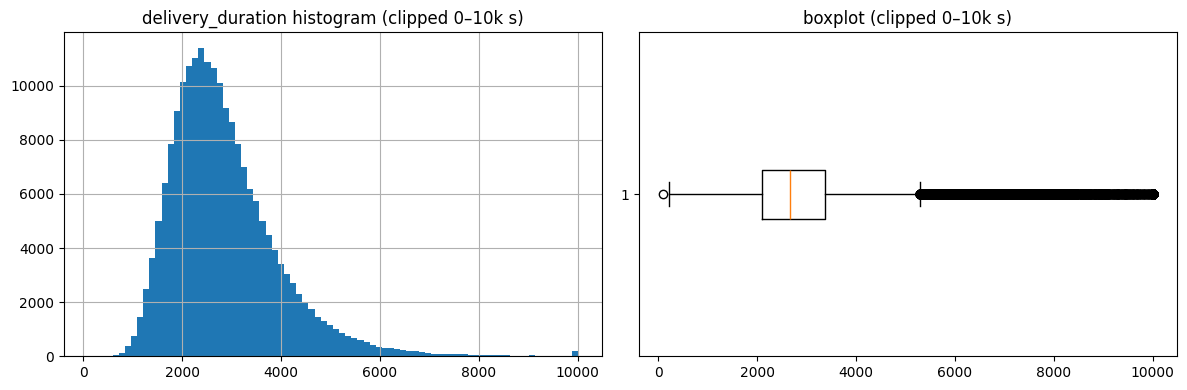

In [107]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['delivery_duration'].clip(0, 10000).hist(bins=80, ax=ax[0])
ax[0].set_title('delivery_duration histogram (clipped 0–10k s)')
ax[1].boxplot(df['delivery_duration'].clip(0, 10000).dropna(), vert=False)
ax[1].set_title('boxplot (clipped 0–10k s)')
plt.tight_layout(); plt.show()

### Feature Distributions

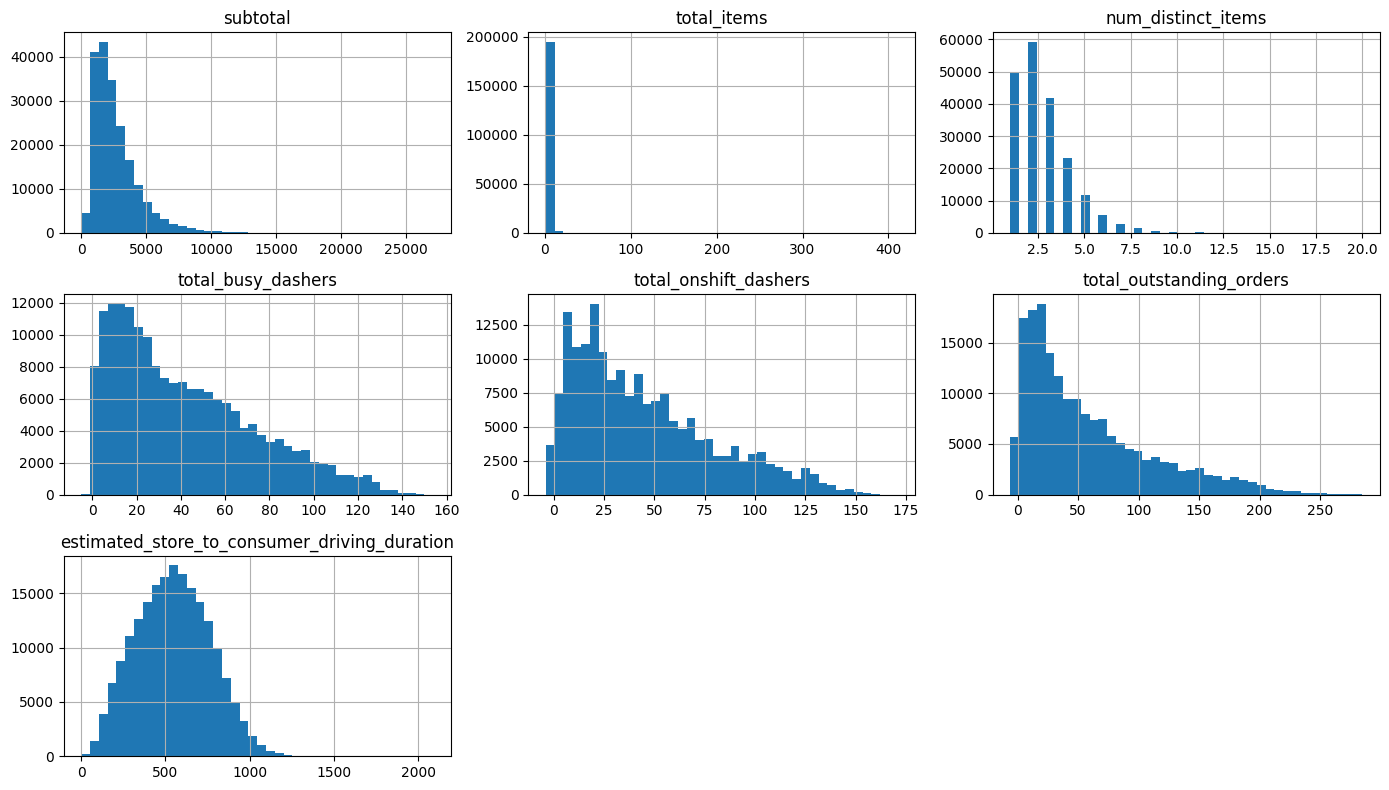

In [108]:
cols = ['subtotal','total_items','num_distinct_items',
        'total_busy_dashers','total_onshift_dashers','total_outstanding_orders',
        'estimated_store_to_consumer_driving_duration']
df[cols].hist(bins=40, figsize=(14, 8))
plt.tight_layout(); plt.show()

### Correlation Heatmap

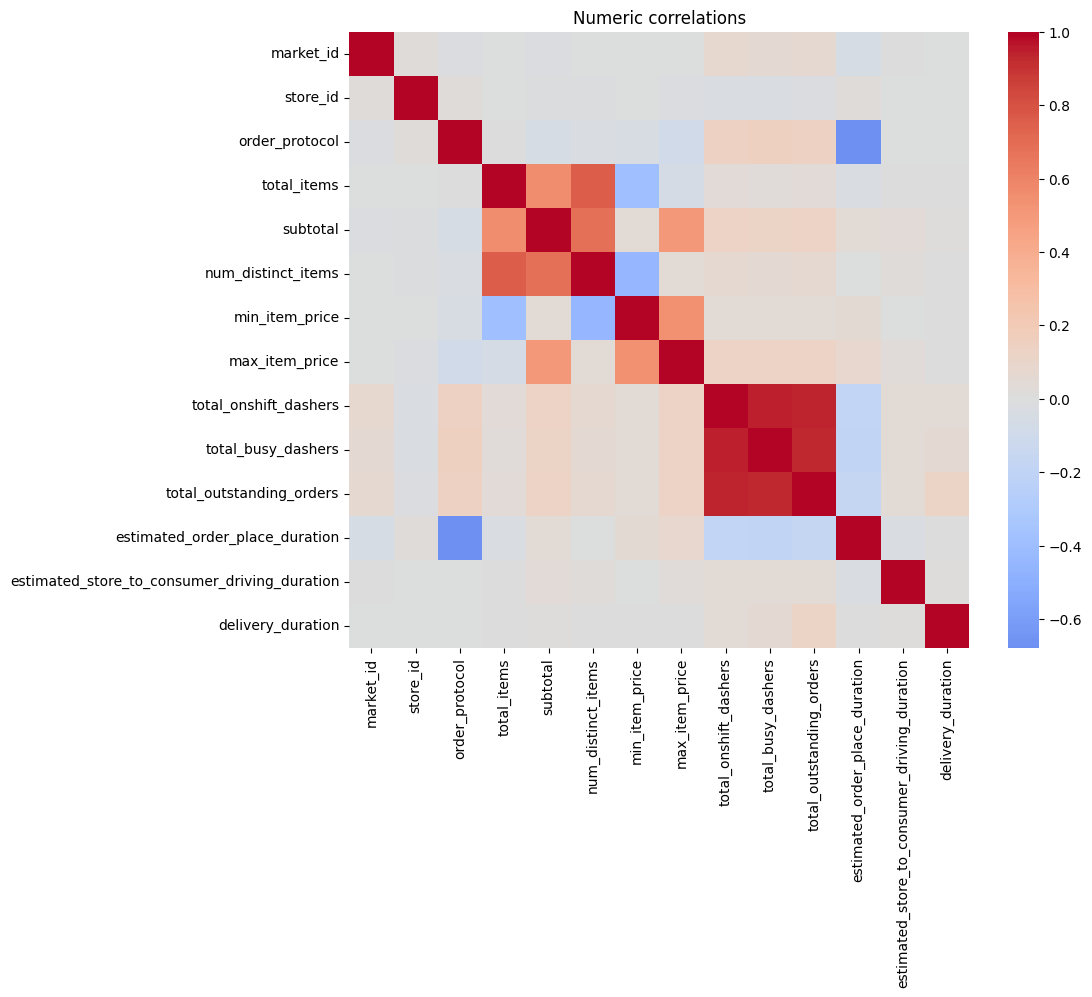

In [109]:
num = df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(num.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Numeric correlations')
plt.show()

In [110]:
num.corr()['delivery_duration'].sort_values(ascending=False)

delivery_duration                               1.000000
total_outstanding_orders                        0.122294
total_busy_dashers                              0.060641
total_onshift_dashers                           0.046972
estimated_store_to_consumer_driving_duration    0.012198
subtotal                                        0.011200
max_item_price                                  0.009409
estimated_order_place_duration                  0.009200
num_distinct_items                              0.006741
total_items                                     0.004905
min_item_price                                  0.004762
store_id                                       -0.000414
market_id                                      -0.005784
order_protocol                                 -0.006660
Name: delivery_duration, dtype: float64

## 3. Slice Analysis

In [111]:
buckets = pd.cut(df['delivery_duration'],
                 [0, 30*60, 60*60, np.inf],
                 labels=['<30min', '30-60min', '>60min'])
buckets.value_counts(normalize=True).sort_index().mul(100).round(1).rename('%').to_frame()

,%
delivery_duration,
<30min,13.2
30-60min,67.0
>60min,19.9


In [112]:
for col in ['market_id', 'order_protocol']:
    tmp = df.groupby(col, dropna=False)['delivery_duration'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(f'\n--- ETA by {col} ---')
    print(tmp.round(1))


--- ETA by market_id ---
             mean  count
market_id               
1.0        3312.4  38037
NaN        2878.0    987
3.0        2861.7  23296
4.0        2842.0  47597
6.0        2835.5  14450
5.0        2789.7  17999
2.0        2764.4  55055

--- ETA by order_protocol ---
                  mean  count
order_protocol               
6.0             3665.2    794
1.0             3151.2  54723
4.0             2905.9  19353
2.0             2841.9  24051
3.0             2817.7  53197
NaN             2810.7    995
5.0             2742.7  44289
7.0             2482.2     19


In [113]:
cat = (df.groupby('store_primary_category', dropna=False)['delivery_duration']
         .agg(['mean', 'count']).sort_values('mean', ascending=False))
print('--- highest-ETA categories (n ≥ 100) ---')
print(cat[cat['count'] >= 100].head(10).round(1))
print('\n--- lowest-ETA categories (n ≥ 100) ---')
print(cat[cat['count'] >= 100].tail(10).round(1))

--- highest-ETA categories (n ≥ 100) ---
                          mean  count
store_primary_category               
italian                 4212.1   7179
caribbean               3365.9    253
brazilian               3358.4    310
tapas                   3255.0    146
cajun                   3150.1    316
malaysian               3137.4    102
japanese                3124.7   9195
afghan                  3099.8    119
burmese                 3098.1    821
steak                   3095.6   1092

--- lowest-ETA categories (n ≥ 100) ---
                          mean  count
store_primary_category               
persian                 2749.0    607
vietnamese              2720.7   6095
hawaiian                2719.6   1499
breakfast               2699.4   5425
alcohol                 2697.5   1850
sandwich                2685.6  10059
smoothie                2681.5   1659
mexican                 2672.8  17098
turkish                 2666.5    237
fast                    2631.2   7371


In [114]:
hr  = df['created_at'].dt.hour
dow = df['created_at'].dt.dayofweek
print('--- ETA by hour-of-day ---')
print(df.groupby(hr)['delivery_duration'].mean().round(1))
print('\n--- ETA by day-of-week (Mon=0) ---')
print(df.groupby(dow)['delivery_duration'].mean().round(1))

--- ETA by hour-of-day ---
created_at
0       2648.0
1       2936.3
2       3299.2
3       3154.1
4       2676.4
5       3602.7
6       2444.8
7       2755.0
8     203284.5
14      4057.6
15      3183.3
16      2862.3
17      2654.8
18      2456.7
19      2771.3
20      2656.0
21      2465.2
22      2526.9
23      2609.1
Name: delivery_duration, dtype: float64

--- ETA by day-of-week (Mon=0) ---
created_at
0    3102.8
1    2779.8
2    2668.3
3    2826.1
4    2684.8
5    3005.2
6    3163.2
Name: delivery_duration, dtype: float64


## 4. Leakage & Time Discipline

In [115]:
span = df['created_at'].agg(['min', 'max'])
print(span.to_string())
print(f'span: {(span["max"] - span["min"]).days} days')

min   2014-10-19 05:24:15
max   2015-02-18 06:00:44
span: 122 days
